TALLER #4   APRENDIZAJE NO SUPERVISADO - CLUSTERING.  
    
     ACTIVIDAD SPOTIFY 
     

1. Importaremos las liberías necesarias, seguidamente cargaremos el dataset con el que trabajaremos.
2. Realizaremos limpieza de datos y estandarización de Variables.
3. Reducción de la dimensionalidad.
4. Modelado usando K-Means
5. Entreno de Modelo.
6. Visualización y análisis.
7. Conclusión.


In [64]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster  import KMeans, DBSCAN
from sklearn.metrics import silhouette_score

In [65]:
df = pd.read_csv(r"C:\Users\lolit\Downloads\spotifydataset.csv")

df.dropna()


,Unnamed: 0,artist_name,genres,followers,artist_popularity,artist_url,track_name,album_name,release_date,duration_ms,...,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo
0,0,Ariana Grande,pop,98934105,89,https://open.spotify.com/artist/66CXWjxzNUsdJx...,we can't be friends (wait for your love),eternal sunshine,2024-03-08,228639,...,0.646,5,-8.334,1,0.0427,0.0615,0.000030,0.0740,0.295,115.842
1,1,Ariana Grande,pop,98934105,85,https://open.spotify.com/artist/66CXWjxzNUsdJx...,the boy is mine,eternal sunshine,2024-03-08,173639,...,0.630,7,-5.854,0,0.0434,0.1570,0.000000,0.0732,0.447,97.998
2,2,Ariana Grande,pop,98934105,83,https://open.spotify.com/artist/66CXWjxzNUsdJx...,intro (end of the world),eternal sunshine,2024-03-08,92400,...,0.362,10,-9.480,1,0.0416,0.6700,0.000000,0.1760,0.385,84.726
3,3,Ariana Grande,pop,98934105,80,https://open.spotify.com/artist/66CXWjxzNUsdJx...,Save Your Tears (Remix) (with Ariana Grande) -...,After Hours (Deluxe),2020-03-20,191013,...,0.825,0,-4.645,1,0.0325,0.0215,0.000024,0.0936,0.593,118.091
4,4,Ariana Grande,pop,98934105,79,https://open.spotify.com/artist/66CXWjxzNUsdJx...,"yes, and?",eternal sunshine,2024-03-08,214994,...,0.775,1,-6.614,1,0.0548,0.1900,0.000065,0.1130,0.787,118.998
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,995,Outkast,"atl hip hop, dirty south rap, hip hop, old sch...",2769972,69,https://open.spotify.com/artist/1G9G7WwrXka3Z1...,Roses,Speakerboxxx/The Love Below,2003,369573,...,0.708,0,-5.653,1,0.0545,0.0482,0.000018,0.1070,0.509,108.970
996,996,Outkast,"atl hip hop, dirty south rap, hip hop, old sch...",2769972,64,https://open.spotify.com/artist/1G9G7WwrXka3Z1...,Rosa Parks,Aquemini,1998-09-29,324373,...,0.701,6,-7.198,0,0.2830,0.1050,0.000000,0.7610,0.251,103.890
997,997,Outkast,"atl hip hop, dirty south rap, hip hop, old sch...",2769972,60,https://open.spotify.com/artist/1G9G7WwrXka3Z1...,B.O.B. - Bombs Over Baghdad,Stankonia,2000-10-31,304226,...,0.978,9,-5.324,1,0.0978,0.0555,0.000041,0.0260,0.653,153.809
998,998,Outkast,"atl hip hop, dirty south rap, hip hop, old sch...",2769972,59,https://open.spotify.com/artist/1G9G7WwrXka3Z1...,Da Art of Storytellin' (Pt. 1),Aquemini,1998-09-29,222653,...,0.856,2,-5.833,1,0.2350,0.1070,0.000000,0.7450,0.402,103.773


In [66]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 23 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Unnamed: 0         1000 non-null   int64  
 1   artist_name        1000 non-null   str    
 2   genres             837 non-null    str    
 3   followers          1000 non-null   int64  
 4   artist_popularity  1000 non-null   int64  
 5   artist_url         1000 non-null   str    
 6   track_name         1000 non-null   str    
 7   album_name         1000 non-null   str    
 8   release_date       1000 non-null   str    
 9   duration_ms        1000 non-null   int64  
 10  explicit           1000 non-null   bool   
 11  track_popularity   1000 non-null   int64  
 12  danceability       1000 non-null   float64
 13  energy             1000 non-null   float64
 14  key                1000 non-null   int64  
 15  loudness           1000 non-null   float64
 16  mode               1000 non-null   i

In [67]:
audio = [
    'danceability',
    'track_popularity',
    'energy',
    'key',
    'loudness',
    'mode',
    'speechiness',
    'acousticness',
    'instrumentalness',
    'liveness',
    'valence',
    'tempo'
]


In [68]:
df_filtro = df[audio].copy()


In [69]:
print("Valores nulos por columna")
print(df_filtro.isnull().sum())

Valores nulos por columna
danceability        0
track_popularity    0
energy              0
key                 0
loudness            0
mode                0
speechiness         0
acousticness        0
instrumentalness    0
liveness            0
valence             0
tempo               0
dtype: int64


In [70]:
df_filtro = df_filtro.dropna()
 

In [71]:
df_filtro.head()

,danceability,track_popularity,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo
0,0.645,89,0.646,5,-8.334,1,0.0427,0.0615,0.000030,0.0740,0.295,115.842
1,0.795,85,0.630,7,-5.854,0,0.0434,0.1570,0.000000,0.0732,0.447,97.998
2,0.506,83,0.362,10,-9.480,1,0.0416,0.6700,0.000000,0.1760,0.385,84.726
3,0.650,80,0.825,0,-4.645,1,0.0325,0.0215,0.000024,0.0936,0.593,118.091
4,0.787,79,0.775,1,-6.614,1,0.0548,0.1900,0.000065,0.1130,0.787,118.998


In [72]:
scaler = StandardScaler()
datos_escalados = scaler.fit_transform(df_filtro)

In [73]:
#Reducimos los datos y luego convertir el df para su fácil manipulación

pca = PCA(n_components=2)
datos_pca = pca.fit_transform(datos_escalados)

df_pca = pd.DataFrame(data=datos_pca, columns=['Componente 1', 'Componente 2'])

In [74]:
#Modelado

numero_clusters = 3
kmeans = KMeans(n_clusters=numero_clusters, random_state=42, n_init=10)


In [75]:
#Entrenamos el modelo

df_filtro['Cluster'] = kmeans.fit_predict(datos_escalados)
df_pca['Cluster'] = df_filtro['Cluster'].values

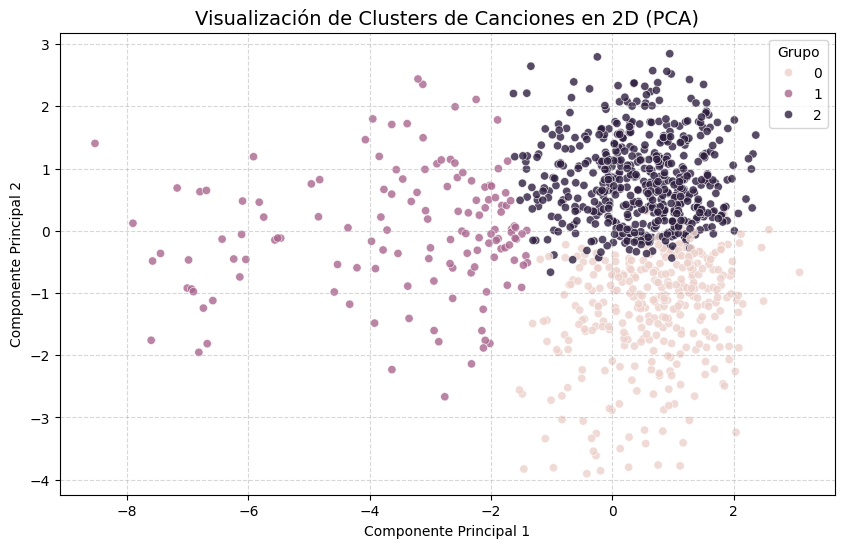

In [76]:
#Visualización 

plt.figure(figsize=(10, 6))
sns.scatterplot(
    x='Componente 1',
    y='Componente 2',
    hue='Cluster',
    data=df_pca,
    alpha=0.8
)


plt.title('Visualización de Clusters de Canciones en 2D (PCA)', fontsize=14)
plt.xlabel('Componente Principal 1')
plt.ylabel('Componente Principal 2')
plt.legend(title='Grupo')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()




In [77]:
print("\n--- Características promedio por cada grupo (Cluster) ---")
print(df_filtro.groupby('Cluster').mean())


--- Características promedio por cada grupo (Cluster) ---
         danceability  track_popularity    energy       key   loudness  \
Cluster                                                                  
0            0.519105         56.330330  0.802015  5.039039  -5.191619   
1            0.463000         45.079710  0.315523  5.224638 -14.562058   
2            0.708268         65.122873  0.661529  5.376181  -6.468809   

             mode  speechiness  acousticness  instrumentalness  liveness  \
Cluster                                                                    
0        0.738739     0.086724      0.096820          0.061438  0.280081   
1        0.695652     0.053964      0.727229          0.373967  0.133055   
2        0.512287     0.104112      0.251874          0.004979  0.145901   

          valence       tempo  
Cluster                        
0        0.447537  136.913435  
1        0.323320  117.537652  
2        0.610574  114.047406  


CONCLUSIÓN



             CLUSTER 0  ÉXITOS ENÉRGICOS


Son canciones rápidas, con potencia, estas son ideales para fiestas o para entrenamientos de alto impacto.



             CLUSTER 1  RITMO Y BAILE


Esta es de música urbana o bailable, se enfoca en el ritmo, canciones donde la voz tienen el protagonismo.



             CLUSTER 2  RELAX Y ACÚSTICO
             
             
Son temas más tranquilos, perfectos para la concentración o relajarse por su baja velocidad.             
    

                                                                                                     LOLA REINA 
                                                                                                     DATA SCIENCE